# Iris Dataset Classification

This notebook builds a classification model on the classic Iris dataset using a **Random Forest Classifier**.

Steps:
1. Load & explore the dataset
2. Visualize the data
3. Train / test split
4. Train the model
5. Evaluate performance

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Reproducibility
RANDOM_STATE = 42

## 1. Load & Explore the Dataset

In [2]:
# Load iris from sklearn (no internet required)
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f"Dataset shape: {df.shape}")
print(f"Classes: {list(iris.target_names)}")
df.head()

Dataset shape: (150, 5)
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Basic statistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Class distribution
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 2. Data Visualization

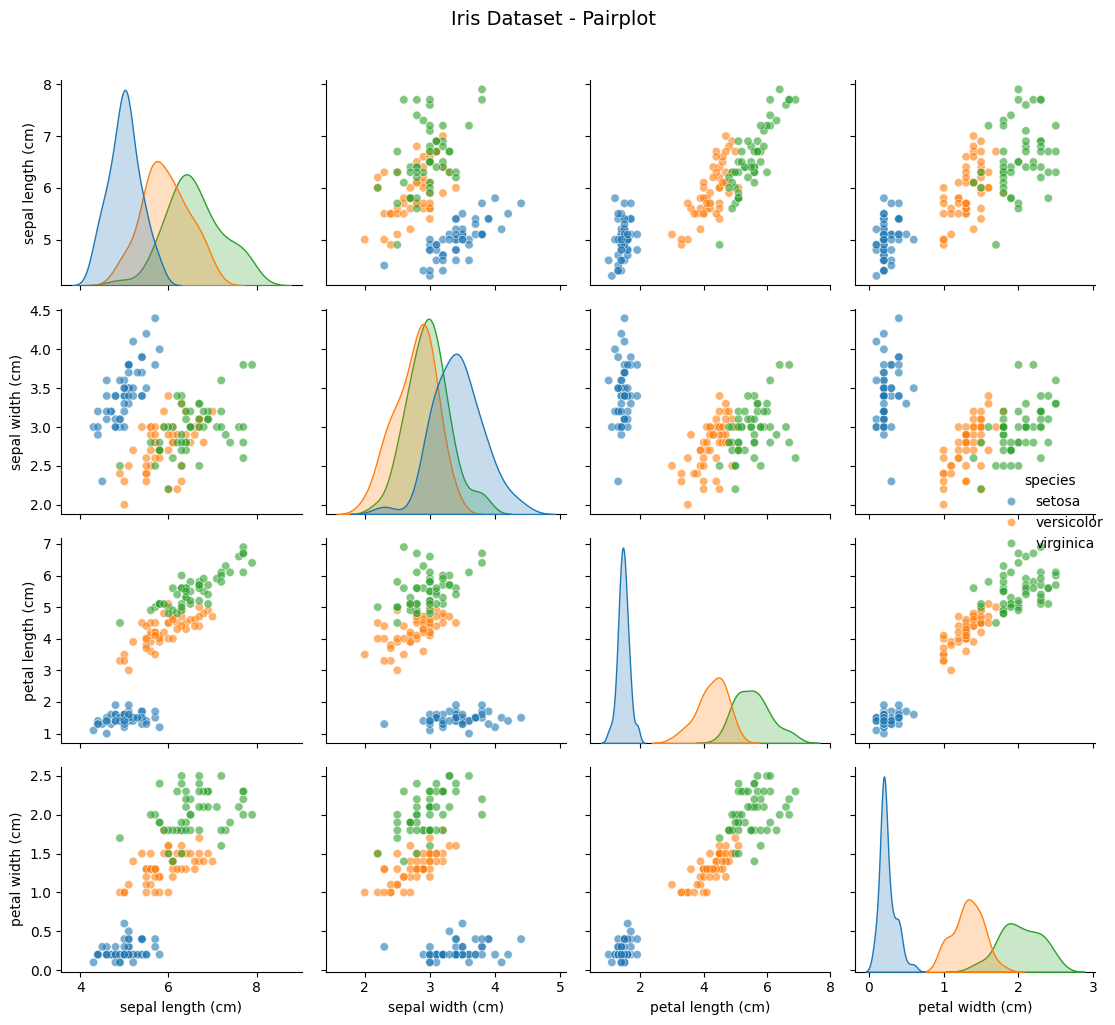

In [5]:
# Pairplot to visualize feature relationships
sns.pairplot(df, hue="species", diag_kind="kde", plot_kws={"alpha": 0.6})
plt.suptitle("Iris Dataset - Pairplot", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

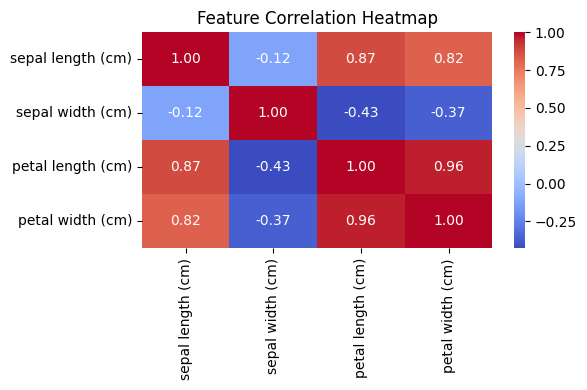

In [6]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    df.drop(columns="species").corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    ax=ax,
)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 3. Train / Test Split

In [7]:
X = iris.data        # Feature matrix (4 features)
y = iris.target      # Labels (0, 1, 2)

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

Training samples : 120
Test samples     : 30


## 4. Train the Random Forest Classifier

In [8]:
clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
clf.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


## 5. Evaluate the Model

In [9]:
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Test Accuracy: 0.9000

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



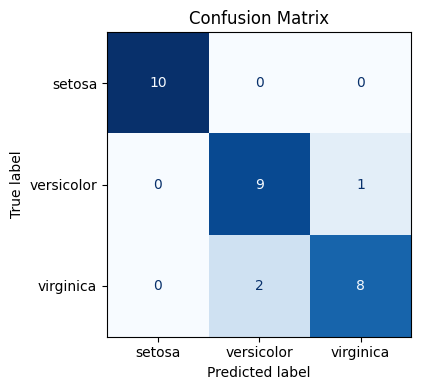

In [10]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

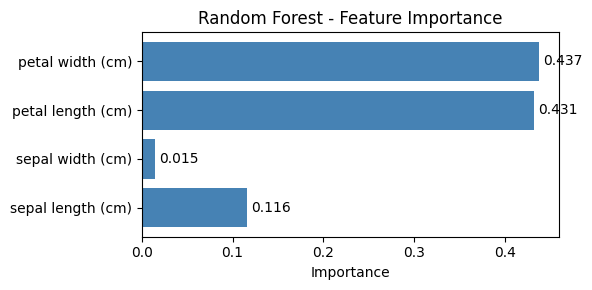

In [11]:
# Feature importance
importances = clf.feature_importances_
feat_names = iris.feature_names

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.barh(feat_names, importances, color="steelblue")
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_xlabel("Importance")
ax.set_title("Random Forest - Feature Importance")
plt.tight_layout()
plt.show()